In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os


In [2]:
expression_file = "../data/raw/expression_matrix.csv"

metadata_file = "../data/metadata/sample_metadata.csv"

figure_folder = "../figures"


os.makedirs(
    figure_folder,
    exist_ok=True
)

In [3]:
expression_df = pd.read_csv(
    expression_file
)

expression_df.head()

,ID_REF,VALUE,ABS_CALL,DETECTION P-VALUE,Sample
0,AFFX-BioB-5_at,276.48065,P,0.000754,GSM119615
1,AFFX-BioB-M_at,391.85696,P,0.000169,GSM119615
2,AFFX-BioB-3_at,269.12082,P,0.000095,GSM119615
3,AFFX-BioC-5_at,852.27240,P,0.000095,GSM119615
4,AFFX-BioC-3_at,821.93243,P,0.000044,GSM119615


In [4]:
expression_df.shape

(8802675, 5)

In [5]:
metadata_df = pd.read_csv(
    metadata_file
)

metadata_df.head()

,Sample,Title,Source,Organism,Characteristics
0,GSM119615,EC control 1,"brain, Entorhinal Cortex",Homo sapiens,Sample Amount: 10 ug; Bio-Source Name: EC cont...
1,GSM119616,EC control 2,"brain, Entorhinal Cortex",Homo sapiens,Sample Amount: 10 ug; Bio-Source Name: EC cont...
2,GSM119617,EC control 3,"brain, Entorhinal Cortex",Homo sapiens,Sample Amount: 10 ug; Bio-Source Name: EC cont...
3,GSM119618,EC control 4,"brain, Entorhinal Cortex",Homo sapiens,Sample Amount: 10 ug; Bio-Source Name: EC cont...
4,GSM119619,EC control 5,"brain, Entorhinal Cortex",Homo sapiens,Sample Amount: 10 ug; Bio-Source Name: EC cont...


In [6]:
expression_df.isnull().sum()

ID_REF               0
VALUE                0
ABS_CALL             0
DETECTION P-VALUE    0
Sample               0
dtype: int64

In [7]:
expression_df.describe()

,VALUE,DETECTION P-VALUE
count,8.802675e+06,8.802675e+06
mean,2.643755e+02,3.298759e-01
std,1.314646e+03,3.344938e-01
min,5.537930e-02,0.000000e+00
25%,1.470500e+01,1.074220e-02
50%,5.404130e+01,2.194820e-01
75%,1.665070e+02,6.337890e-01
max,5.280435e+05,9.997560e-01


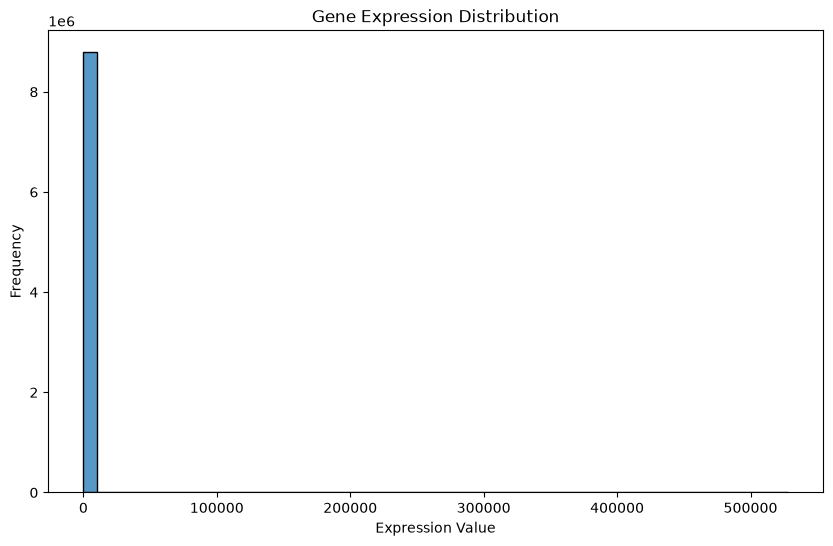

In [8]:
plt.figure(figsize=(10,6))


sns.histplot(
    expression_df.iloc[:,1],
    bins=50
)


plt.title(
    "Gene Expression Distribution"
)


plt.xlabel(
    "Expression Value"
)


plt.ylabel(
    "Frequency"
)


plt.savefig(
    "../figures/expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [9]:
# Convert long-format expression data into gene x sample matrix

expression_matrix = expression_df.pivot_table(
    index="ID_REF",
    columns="Sample",
    values="VALUE",
    aggfunc="mean"
)


expression_matrix.head()

Sample,GSM119615,GSM119616,GSM119617,GSM119618,GSM119619,GSM119620,GSM119621,GSM119622,GSM119623,GSM119624,...,GSM238945,GSM238946,GSM238947,GSM238948,GSM238949,GSM238951,GSM238952,GSM238953,GSM238955,GSM238963
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,693.973300,807.145140,1722.625000,1668.057500,2231.29690,990.541000,1396.82420,1026.056500,736.770300,938.817100,...,983.1340,855.5980,2074.2300,1385.89000,1390.9400,904.4160,1319.0900,783.2270,1552.96000,2845.4500
1053_at,9.755318,19.052270,13.060389,14.652245,138.67683,7.186742,10.17089,34.056934,7.829473,40.235332,...,78.0901,57.5839,4.9474,11.06460,78.2078,50.5737,13.7651,56.3892,6.97840,33.0147
117_at,13.346846,18.217276,97.425470,98.197945,106.46844,98.710520,164.32666,46.306164,35.067910,72.864900,...,35.8215,106.8380,87.6188,39.50480,117.6100,20.6184,31.4041,41.2217,40.48350,19.1316
121_at,173.092450,289.315400,537.182800,496.346560,477.86517,355.092000,467.56790,294.583280,224.524060,298.284730,...,114.5470,174.5280,180.7250,238.92100,221.8730,153.4310,262.5170,136.9680,284.89900,404.0750
1255_g_at,52.616950,110.375984,99.021736,17.306772,628.81616,105.254600,142.26918,123.016136,183.396910,180.814250,...,18.8389,80.0143,69.0884,5.82269,44.7857,11.4650,30.3939,40.7314,4.34157,42.2666


In [ ]:
# Samples must be rows for correlation

sample_expression = expression_matrix.T


correlation_matrix = sample_expression.corr()


correlation_matrix.head()

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix
)

plt.title(
    "Sample Correlation Heatmap"
)

plt.savefig(
    "../figures/sample_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
expression_df.columns

In [ ]:
expression_matrix.shape